In [15]:
import pandas as pd

store_sales = pd.read_csv("store_sales.csv")
store_detail = pd.read_csv("store_detail.csv")
products = pd.read_csv("products.csv")


1. Create a list of all transactions from January 2024, sorted by sale amount from highest to lowest. Which transactions had a sale amount greater than $500?

In [16]:
# Filter transactions from January 2024
jan_2024 = store_sales[
    (pd.to_datetime(store_sales["Transaction Date"]).dt.year == 2024) &
    (pd.to_datetime(store_sales["Transaction Date"]).dt.month == 1)
]

# Sort by sale amount (descending)
jan_2024_sorted = jan_2024.sort_values("Sale Amount", ascending=False)

jan_2024_sorted.head()


,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount
133164,1/1/2024,726,NaN,105341-IT,1763.7
139709,1/31/2024,822,NaN,105341-IT,1763.7
136870,1/18/2024,736,NaN,105341-IT,1763.7
135291,1/10/2024,823,337.0,105341-IT,1763.7
138720,1/27/2024,701,NaN,105341-IT,1763.7


In [17]:
high_value_txns = jan_2024_sorted[jan_2024_sorted["Sale Amount"] > 500]
high_value_txns


,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount
133164,1/1/2024,726,NaN,105341-IT,1763.7
139709,1/31/2024,822,NaN,105341-IT,1763.7
136870,1/18/2024,736,NaN,105341-IT,1763.7
135291,1/10/2024,823,337.0,105341-IT,1763.7
138720,1/27/2024,701,NaN,105341-IT,1763.7
...,...,...,...,...,...
139560,1/30/2024,910,NaN,105262-IT,603.5
136218,1/15/2024,728,NaN,105262-IT,603.5
137647,1/22/2024,714,NaN,105262-IT,603.5
133401,1/2/2024,726,NaN,105262-IT,603.5


2. Find all products whose product number begins with 10525. What category and subcategory do they belong to?

In [18]:
products.columns


Index(['Prod Num', 'Product', 'CategoryID', 'SubcategoryID'], dtype='str')

In [19]:
 # Filter products starting with 10525
products_10525 = products[products["Prod Num"].astype(str).str.startswith("10525")]

products_10525[["Prod Num", "CategoryID", "SubcategoryID"]]



,Prod Num,CategoryID,SubcategoryID
2,105250-IT,120,120-tab
3,105251-IT,120,120-tab
4,105252-IT,120,120-tab
5,105253-IT,120,120-tab
6,105254-IT,120,120-tab
7,105255-IT,120,120-tab
8,105256-IT,120,120-tab
9,105257-IT,120,120-tab
10,105258-IT,120,120-tab
11,105259-IT,120,120-tab


3. Which stores in your assigned territories had at least one transaction with a sale amount over $1,000? How many such transactions did each store have?

In [26]:
# Merge sales with store details
sales_with_store = store_sales.merge(
    store_detail,
    on="Store ID",
    how="left"
)

# Filter to assigned territories (East region)
assigned_sales = sales_with_store[sales_with_store["Region"] == "East"]

# Filter transactions > $1000
high_value_sales = assigned_sales[assigned_sales["Sale Amount"] > 1000]

# Count transactions per store
# Using the correct column: "Store Location"
store_high_value_counts = (
    high_value_sales
    .groupby(["Store ID", "Store Location", "State"])["Sale Amount"]
    .count()
    .reset_index(name="High Value Transaction Count")
)

store_high_value_counts


,Store ID,Store Location,State,High Value Transaction Count
0,840,Albany,New York,85
1,841,Buffalo,New York,87
2,842,Elmira,New York,88
3,843,Ithaca,New York,80
4,844,Oswego,New York,83
5,845,Plattsburgh,New York,95
6,846,Poestenkill,New York,107
7,847,Rochester,New York,167
8,848,Syracuse,New York,78
9,849,Brooklyn,New York,83


In [ ]:
sales_with_store.columns


Index(['Transaction Date', 'Store ID', 'RewardsID', 'Prod Num', 'Sale Amount',
       'Store Location', 'State', 'Territory Manager', 'Region',
       'Region Director'],
      dtype='str')

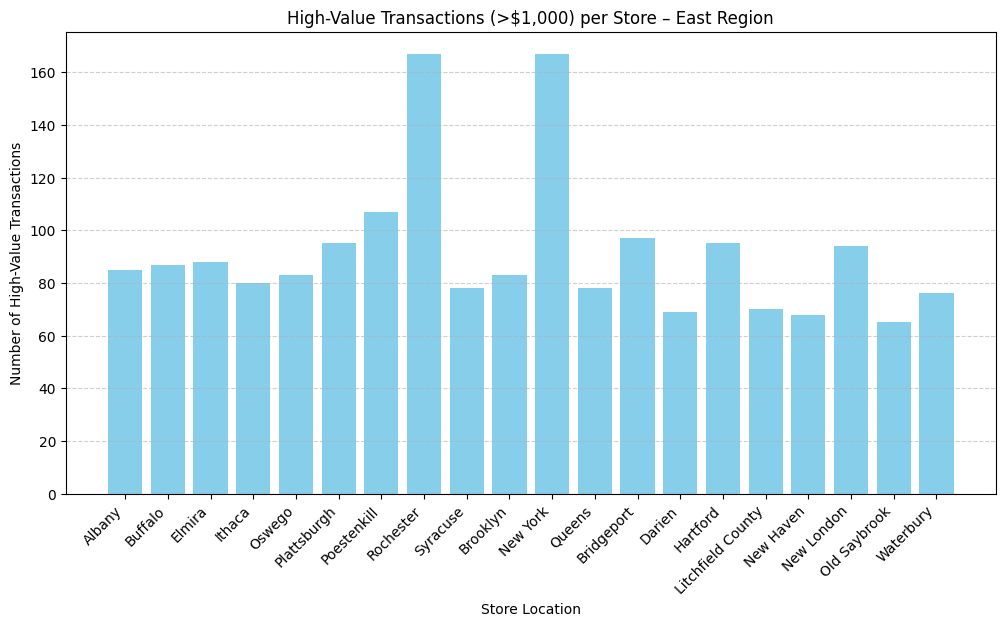

In [ ]:

import matplotlib.pyplot as plt

# Merging sales with store details so I can see which store each transaction belongs to.
sales_with_store = store_sales.merge(
    store_detail,
    on="Store ID",
    how="left"
)

# Filtering to only the East region since that's my assigned territory.
assigned_sales = sales_with_store[sales_with_store["Region"] == "East"]

# Pulling out only the transactions that were over $1000.
high_value_sales = assigned_sales[assigned_sales["Sale Amount"] > 1000]

# Grouping by store to count how many high-value transactions each store had.
# Using the correct column names: "Store ID" and "Store Location"
store_high_value_counts = (
    high_value_sales
    .groupby(["Store ID", "Store Location"])["Sale Amount"]
    .count()
    .reset_index(name="High Value Transaction Count")
)

# Creating a bar chart to compare stores.
plt.figure(figsize=(12,6))
plt.bar(
    store_high_value_counts["Store Location"],
    store_high_value_counts["High Value Transaction Count"],
    color="skyblue"
)

# Adding a clear title and labels so the chart is easy to understand.
plt.title("High-Value Transactions (>$1,000) per Store – East Region")
plt.xlabel("Store Location")
plt.ylabel("Number of High-Value Transactions")

# Rotating the x labels so the store names don't overlap.
plt.xticks(rotation=45, ha="right")

# Adding a light grid to make the values easier to read.
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.show()


This bar chart shows how many transactions over $1,000 each store in the East region processed. I used a bar chart because it clearly compares stores as categories. Each bar represents a store location, and the height shows how many high‑value sales it had. This helps identify which stores generate the biggest purchases and where the strongest revenue opportunities are.

Advanced/ Stretch

13. Compare year‑over‑year revenue for your territories. Is each territory trending up or down between years?

#Below, I grouped revenue by year for my assigned territory and compared how revenue changed from one year to the next. This helps me see whether the territory is trending upward or downward over time.

In [21]:
# Making sure the date column is in datetime format
sales_with_store["Transaction Date"] = pd.to_datetime(sales_with_store["Transaction Date"])

# Extracting the year
sales_with_store["Year"] = sales_with_store["Transaction Date"].dt.year

# Filtering to my assigned territory (East)
east_sales = sales_with_store[sales_with_store["Region"] == "East"]

# Grouping by year to get total revenue per year
yearly_revenue = (
    east_sales.groupby("Year")["Sale Amount"]
    .sum()
    .reset_index(name="Total Revenue")
)

yearly_revenue


,Year,Total Revenue
0,2022,1086634.60
1,2023,1597181.48
2,2024,1602617.98
3,2025,2436605.47


14. Identify the single best month and single worst month for each of your territories over the full data period.

#I calculated monthly revenue totals and then identified which month had the highest revenue and which had the lowest. This helps highlight seasonal patterns and performance peaks.

In [24]:
# Make sure date is datetime
sales_with_store["Transaction Date"] = pd.to_datetime(sales_with_store["Transaction Date"])

# Create Year-Month column on the full dataframe
sales_with_store["YearMonth"] = sales_with_store["Transaction Date"].dt.to_period("M")

# Filter to East region AFTER creating YearMonth
east_sales = sales_with_store[sales_with_store["Region"] == "East"]

# Monthly revenue for East region
monthly_revenue = (
    east_sales.groupby("YearMonth")["Sale Amount"]
    .sum()
    .reset_index(name="Monthly Revenue")
)

# Best month
best_month = monthly_revenue.loc[monthly_revenue["Monthly Revenue"].idxmax()]

# Worst month
worst_month = monthly_revenue.loc[monthly_revenue["Monthly Revenue"].idxmin()]

best_month, worst_month


(YearMonth            2025-10
 Monthly Revenue    301070.13
 Name: 45, dtype: object,
 YearMonth          2022-11
 Monthly Revenue    84353.1
 Name: 10, dtype: object)

15. Using your monthly revenue totals, fit a linear regression model to the data and plot the trend line alongside the monthly revenue chart. Is your territory trending up or down overall?

#15.I used a simple linear regression model to see whether monthly revenue is trending upward or downward. The trend line helps visualize the long‑term direction of revenue. 

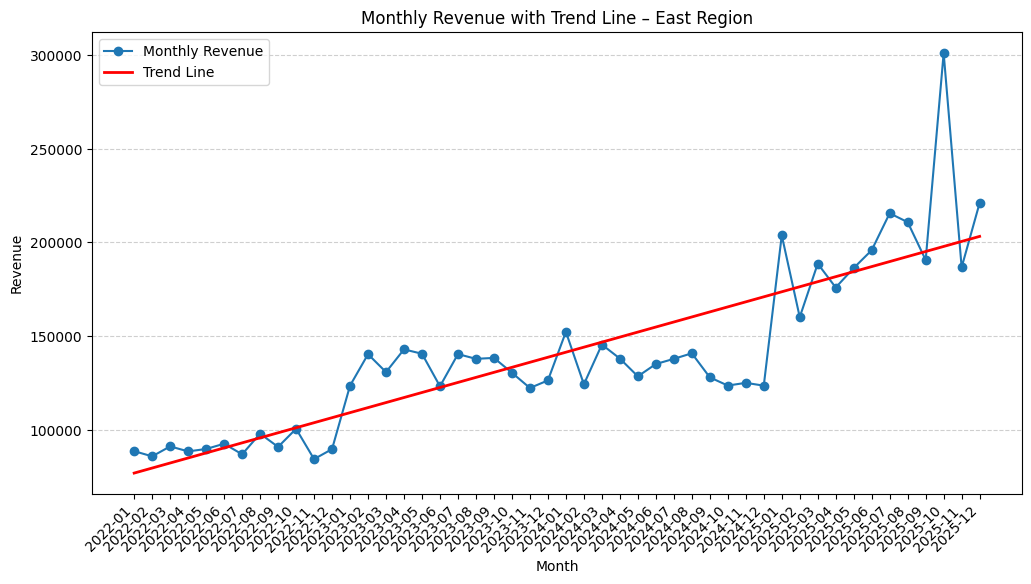

In [27]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np

# Converting YearMonth to a numeric index for regression
monthly_revenue["MonthIndex"] = np.arange(len(monthly_revenue))

# Preparing X and y for regression
X = monthly_revenue["MonthIndex"].values.reshape(-1, 1)
y = monthly_revenue["Monthly Revenue"].values

# Fitting the linear regression model
model = LinearRegression()
model.fit(X, y)

# Predicting the trend line
trend_line = model.predict(X)

# Plotting the monthly revenue and the trend line
plt.figure(figsize=(12,6))

# Actual revenue
plt.plot(monthly_revenue["YearMonth"].astype(str), monthly_revenue["Monthly Revenue"],
         label="Monthly Revenue", marker="o")

# Trend line
plt.plot(monthly_revenue["YearMonth"].astype(str), trend_line,
         label="Trend Line", color="red", linewidth=2)

plt.title("Monthly Revenue with Trend Line – East Region")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.show()


The trend line shows whether revenue is increasing or decreasing over time. If the red line slopes upward, the territory is trending up. If it slopes downward, the territory is trending down. This helps me understand long‑term performance beyond month‑to‑month fluctuations